# CARA: BLEU gains without sacrificing round-trip correctness

**Claim tested in this notebook:** CARA significantly improves BLEU over zero-shot
prompting, and — unlike ASAP (the current SOTA baseline we compare against) — it does
so **without a practically significant drop in round-trip correctness (RTC)**.

**Data.** All numbers come from MLflow runs already logged under this project's
tracking store (`mlflow-data/`), evaluated on the same 2000 matched
`(project, func_name, id)` samples per run (full dataset, Python + Java), for two
backbones: Llama-3.3-70B-Instruct and Llama-3.1-8B-Instruct (via OpenRouter).

- **BLEU** — sentence BLEU between the generated summary and the human reference summary.
- **RTC-CrystalBLEU / RTC-CodeBLEU** — round-trip correctness: a backward model
  (`gpt-4o-mini`) resynthesizes the function from the generated summary, and the
  result is compared back to the *original* code with CrystalBLEU / CodeBLEU. Higher
  RTC means the summary better preserves the information needed to reconstruct the
  actual behavior of the code — it is a faithfulness signal, independent of BLEU's
  surface-form match to a human reference.

**Practical-significance bar.** With n=2000 paired samples, Wilcoxon signed-rank
tests find *every* comparison below statistically significant (p < 0.05) — including
differences too small to matter for the paper's claim. So each comparison below is
tagged:
- `**` — statistically significant **and** the mean difference exceeds 2 points
  (treated here as the threshold for a difference worth claiming in prose)
- `*` — statistically significant but the mean difference is ≤ 2 points (real, but
  not something we'd claim as "hurts/helps" in the paper)
- *(blank)* — not statistically significant


In [2]:
import sys
sys.path.insert(0, "/home/phuc/code-sum/src")

import csv

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon, rankdata

from mas_code_sum.evaluator import bleu as _bleu

pd.set_option("display.float_format", lambda x: f"{x:.2f}")


## 1. Run registry and data loading

All 9 runs used: zero-shot, few-shot, ASAP, and CARA for both model sizes, plus the
CodeT5 fine-tuned baseline (model-agnostic). Predictions are read directly from the
MLflow artifact CSVs; BLEU is computed per-row here, RTC-CrystalBLEU/RTC-CodeBLEU are
already logged per-row by the RTC pipeline.

In [ ]:
REPO_ROOT = "/home/phuc/code-sum"

# (method, model) -> MLflow run's predictions CSV. Run IDs are the MLflow run_uuid;
# see `mlflow-data/mlflow.db` (`runs`/`params` tables) for full run provenance.
RUNS = {
    ("zeroshot", "70B"): f"{REPO_ROOT}/mlflow-data/mlartifacts/1/3fc7ad1d11744ad1932039a162c675c3/artifacts/predictions/tmpxgbnm27y.csv",
    ("few_shot", "70B"): f"{REPO_ROOT}/mlflow-data/mlartifacts/1/d1197c3c7e3841508625f4115ff9e999/artifacts/predictions/tmpkv3tkmh3.csv",
    ("asap",     "70B"): f"{REPO_ROOT}/mlflow-data/mlartifacts/1/5005bca877e14c548c05676d439e74a2/artifacts/predictions/tmpjjhyj8w_.csv",
    ("cara",     "70B"): f"{REPO_ROOT}/mlflow-data/mlartifacts/1/68e8ff6fc73848b091804af05a906622/artifacts/predictions/tmp8nv65xz5.csv",
    ("zeroshot", "8B"):  f"{REPO_ROOT}/mlflow-data/mlartifacts/1/38bf994f55064833b046902bba702297/artifacts/predictions/tmpnxnu_qra.csv",
    ("few_shot", "8B"):  f"{REPO_ROOT}/mlflow-data/mlartifacts/1/f39382e451594a448b50ef4cd4e49913/artifacts/predictions/tmpe7dxwypr.csv",
    ("asap",     "8B"):  f"{REPO_ROOT}/mlflow-data/mlartifacts/1/93ac3d2df48c4933b189185db300fac6/artifacts/predictions/tmpfj8c_v82.csv",
    ("cara",     "8B"):  f"{REPO_ROOT}/mlflow-data/mlartifacts/1/9f85a34ec20547caa6f917e8a49b6aad/artifacts/predictions/tmp2igxru9n.csv",
    ("codet5",   None):  f"{REPO_ROOT}/mlflow-data/mlartifacts/1/847b29e632ec4aa7a165f3137f1bbd6d/artifacts/predictions/tmpzgt26372.csv",
}
METHOD_ORDER = ["zeroshot", "few_shot", "asap", "cara", "codet5"]
MODEL_ORDER = ["70B", "8B"]
TOP3 = ["zeroshot", "asap", "cara"]  # the methods the paper's headline story is about
PRACTICAL_THRESHOLD = 2.0  # mean |diff| below this many points isn't claimed as "material"


def load_run(path):
    rows = {}
    with open(path) as f:
        for r in csv.DictReader(f):
            key = (r["project"], r["func_name"], r["id"])
            rows[key] = {
                "bleu": _bleu([r["reference"]], r["prediction"])[0] * 100,
                "rtc_crystalbleu": float(r["rtc_crystalbleu"]),
                "rtc_codebleu": float(r["rtc_codebleu"]),
            }
    return rows


DATA = {name: load_run(path) for name, path in RUNS.items()}
{name: len(rows) for name, rows in DATA.items()}


## 2. Table 1 — Headline means (all methods)

The full picture before narrowing down: BLEU and both RTC metrics, for every method
and model size.

In [12]:
records = []
for (method, model), rows in DATA.items():
    vals = list(rows.values())
    records.append({
        "Method": method,
        "Model": model if model else "-",
        "n": len(vals),
        "BLEU": np.mean([v["bleu"] for v in vals]),
        "RTC-CrystalBLEU": np.mean([v["rtc_crystalbleu"] for v in vals]),
        "RTC-CodeBLEU": np.mean([v["rtc_codebleu"] for v in vals]),
    })
table1 = pd.DataFrame(records)
_order = {m: i for i, m in enumerate(METHOD_ORDER)}
table1["_order"] = table1["Method"].map(_order)
table1 = table1.sort_values(["_order", "Model"]).drop(columns="_order").reset_index(drop=True)
table1


,Method,Model,n,BLEU,RTC-CrystalBLEU,RTC-CodeBLEU
0,zeroshot,70B,2000,10.69,30.57,38.74
1,zeroshot,8B,2000,14.21,27.35,36.36
2,few_shot,70B,2000,23.93,25.76,35.30
3,few_shot,8B,2000,22.01,25.98,35.56
4,asap,70B,2000,24.22,25.46,35.11
5,asap,8B,2000,22.79,25.70,35.36
6,cara,70B,2000,18.37,29.44,37.89
7,cara,8B,2000,19.19,28.03,37.03
8,codet5,-,2000,18.99,24.97,34.66
9,cara2,8B,2000,20.33,27.16,36.38


## 3. Table 2 — Significance vs. zero-shot (all methods)

Paired Wilcoxon signed-rank test, matched by `(project, func_name, id)`, comparing
each prompting method to zero-shot on the same backbone. `d<metric>` is the mean
difference (method − zero-shot); `_sig` uses the `**`/`*`/blank convention defined
above.

In [13]:
def paired_metrics(name_a, name_b):
    a, b = DATA[name_a], DATA[name_b]
    keys = sorted(set(a) & set(b))
    out = {}
    for metric in ["bleu", "rtc_crystalbleu", "rtc_codebleu"]:
        x = np.array([a[k][metric] for k in keys])
        y = np.array([b[k][metric] for k in keys])
        d = x - y
        nz = d[d != 0]
        if len(nz) == 0:
            stat, p, rb = float("nan"), float("nan"), 0.0
        else:
            stat, p = wilcoxon(d, zero_method="wilcox", alternative="two-sided")
            r_ = rankdata(np.abs(nz))
            rb = 2 * r_[nz > 0].sum() / r_.sum() - 1
        out[metric] = dict(n=len(keys), mean_diff=d.mean(), p=p, rank_biserial=rb)
    return out


def sig_flag(p, mean_diff):
    if p < 0.05 and abs(mean_diff) > PRACTICAL_THRESHOLD:
        return "**"
    if p < 0.05:
        return "*"
    return ""


def significance_table(pairs):
    rows = []
    for label, name_a, name_b, model in pairs:
        res = paired_metrics(name_a, name_b)
        row = {"Comparison": label, "Model": model}
        for metric, mlabel in [("bleu", "BLEU"), ("rtc_crystalbleu", "RTC-CrystalBLEU"), ("rtc_codebleu", "RTC-CodeBLEU")]:
            m = res[metric]
            row[f"d{mlabel}"] = m["mean_diff"]
            row[f"{mlabel}_p"] = m["p"]
            row[f"{mlabel}_sig"] = sig_flag(m["p"], m["mean_diff"])
        rows.append(row)
    return pd.DataFrame(rows)


vs_zeroshot_pairs = [
    (f"{method} vs. zeroshot", (method, model), ("zeroshot", model), model)
    for model in MODEL_ORDER
    for method in ["few_shot", "asap", "cara"]
]
table2 = significance_table(vs_zeroshot_pairs)
table2


,Comparison,Model,dBLEU,BLEU_p,BLEU_sig,dRTC-CrystalBLEU,RTC-CrystalBLEU_p,RTC-CrystalBLEU_sig,dRTC-CodeBLEU,RTC-CodeBLEU_p,RTC-CodeBLEU_sig
0,few_shot vs. zeroshot,70B,13.25,0.00,**,-4.81,0.00,**,-3.44,0.00,**
1,asap vs. zeroshot,70B,13.53,0.00,**,-5.11,0.00,**,-3.63,0.00,**
2,cara vs. zeroshot,70B,7.68,0.00,**,-1.13,0.00,*,-0.85,0.00,*
3,few_shot vs. zeroshot,8B,7.81,0.00,**,-1.38,0.00,*,-0.80,0.02,*
4,asap vs. zeroshot,8B,8.58,0.00,**,-1.65,0.00,*,-1.00,0.00,*
5,cara vs. zeroshot,8B,4.98,0.00,**,0.68,0.00,*,0.67,0.00,*


## 4. Table 3 — CARA vs. the CodeT5 baseline

A separate table because CodeT5 is a fine-tuned, non-prompted baseline (no model-size
axis), not part of the zero-shot/ASAP/CARA prompting comparison above.

In [14]:
codet5_pairs = [
    ("cara vs. CodeT5", ("cara", model), ("codet5", None), model)
    for model in MODEL_ORDER
]
table3 = significance_table(codet5_pairs)
table3


,Comparison,Model,dBLEU,BLEU_p,BLEU_sig,dRTC-CrystalBLEU,RTC-CrystalBLEU_p,RTC-CrystalBLEU_sig,dRTC-CodeBLEU,RTC-CodeBLEU_p,RTC-CodeBLEU_sig
0,cara vs. CodeT5,70B,-0.62,0.00,*,4.47,0.00,**,3.23,0.00,**
1,cara vs. CodeT5,8B,0.20,0.00,*,3.06,0.00,**,2.37,0.00,**


## 5. Narrowing to the headline three

Table 2 shows `few_shot` and `asap` move almost identically relative to zero-shot on
every metric and both model sizes — both trade a large BLEU gain for a **practically
significant RTC drop** (`**`, |diff| > 2). Table 3 shows CARA matches CodeT5's BLEU
(difference ≤ 2 points, not practically significant) while beating it clearly on both
RTC metrics.

The figures below therefore focus on the three methods the paper's claim is actually
about: **zero-shot, ASAP (current SOTA), and CARA**.

In [ ]:
colors = {"zeroshot": "#999999", "asap": "#d95f02", "cara": "#1b9e77"}
x = np.arange(len(MODEL_ORDER))
width = 0.25


### Figure 1 — BLEU by method

ASAP and CARA both improve substantially over zero-shot; ASAP's BLEU is somewhat
higher than CARA's.

In [17]:
table1

,Method,Model,n,BLEU,RTC-CrystalBLEU,RTC-CodeBLEU
0,zeroshot,70B,2000,10.69,30.57,38.74
1,zeroshot,8B,2000,14.21,27.35,36.36
2,few_shot,70B,2000,23.93,25.76,35.30
3,few_shot,8B,2000,22.01,25.98,35.56
4,asap,70B,2000,24.22,25.46,35.11
5,asap,8B,2000,22.79,25.70,35.36
6,cara,70B,2000,18.37,29.44,37.89
7,cara,8B,2000,19.19,28.03,37.03
8,codet5,-,2000,18.99,24.97,34.66
9,cara2,8B,2000,20.33,27.16,36.38


In [37]:
MODEL_ORDER = ['8B']

In [20]:
TOP3

['zeroshot', 'asap', 'cara', 'cara2']

In [32]:
method

'zeroshot'

In [34]:
table1[(table1["Method"]==method) & (table1["Model"]==model)]

,Method,Model,n,BLEU,RTC-CrystalBLEU,RTC-CodeBLEU


In [35]:
method,model

('cara2', None)

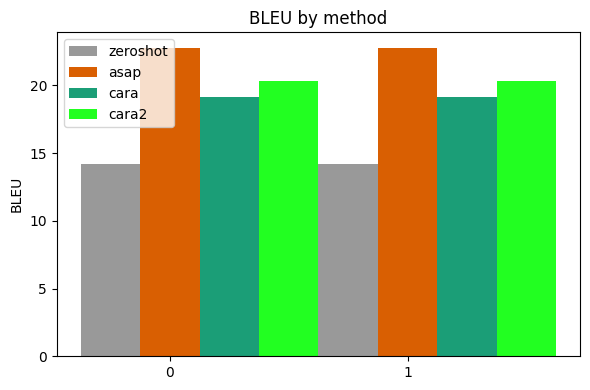

In [39]:
fig, ax = plt.subplots(figsize=(6, 4))
for i, method in enumerate(TOP3):
    means = [table1.query("Method==@method and Model==@model")["BLEU"].iloc[0] for model in MODEL_ORDER]
    ax.bar(x + (i - 1) * width, means, width, label=method, color=colors[method])
ax.set_xticks(x)
#ax.set_xticklabels(MODEL_ORDER)
ax.set_ylabel("BLEU")
ax.set_title("BLEU by method")
ax.legend()
plt.tight_layout()
plt.show()


### Figure 2 — RTC by method

Both RTC metrics tell the same story: ASAP drops noticeably below zero-shot; CARA
stays close to (70B) or above (8B) the zero-shot level.

ValueError: The number of FixedLocator locations (2), usually from a call to set_ticks, does not match the number of labels (1).

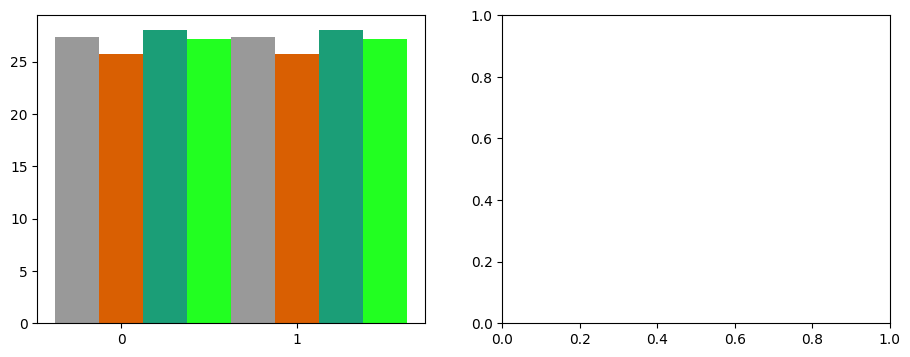

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, metric in zip(axes, ["RTC-CrystalBLEU", "RTC-CodeBLEU"]):
    for i, method in enumerate(TOP3):
        means = [table1.query("Method==@method and Model==@model")[metric].iloc[0] for model in MODEL_ORDER]
        ax.bar(x + (i - 1) * width, means, width, label=method, color=colors[method])
    ax.set_xticks(x)
    ax.set_xticklabels(MODEL_ORDER)
    ax.set_title(metric)
axes[0].set_ylabel("score")
axes[0].legend()
plt.tight_layout()
plt.show()


### Figure 3 — The story chart: Δ BLEU vs. Δ RTC (relative to zero-shot)

Zero-shot pinned at the origin. Upper-right = the ideal outcome (BLEU up, RTC flat or
up). CARA (green) sits at or above the zero-RTC-change line on both metrics and both
model sizes; ASAP (orange) buys a larger BLEU gain at a clearly negative RTC cost on
both metrics and both model sizes.

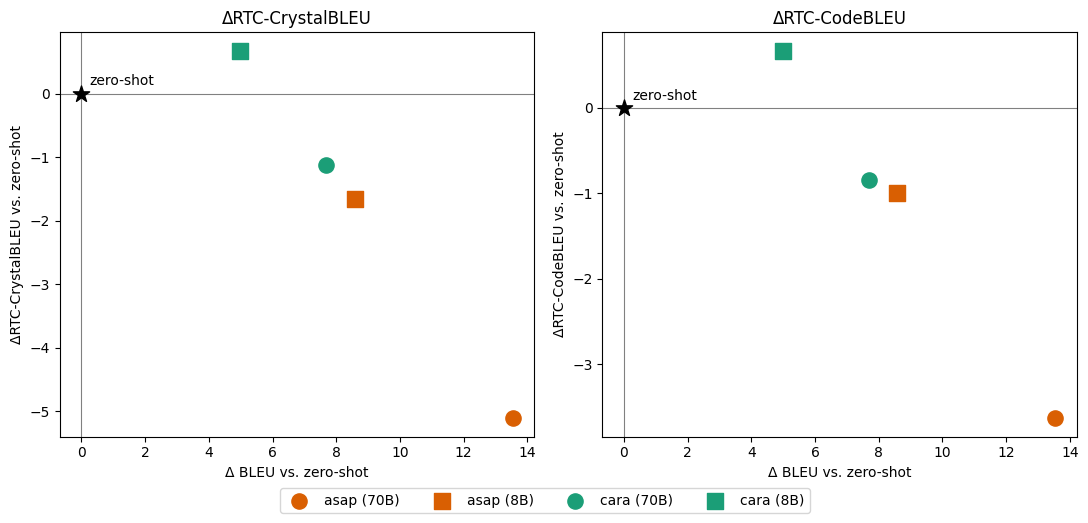

In [9]:
markers = {"70B": "o", "8B": "s"}
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, metric, label in zip(axes, ["rtc_crystalbleu", "rtc_codebleu"], ["ΔRTC-CrystalBLEU", "ΔRTC-CodeBLEU"]):
    for method in ["asap", "cara"]:
        for model in MODEL_ORDER:
            res = paired_metrics((method, model), ("zeroshot", model))
            dx = res["bleu"]["mean_diff"]
            dy = res[metric]["mean_diff"]
            ax.scatter(dx, dy, s=120, marker=markers[model], color=colors[method], label=f"{method} ({model})")
    ax.axhline(0, color="gray", lw=0.8)
    ax.axvline(0, color="gray", lw=0.8)
    ax.scatter(0, 0, color="black", marker="*", s=150, zorder=5)
    ax.annotate("zero-shot", (0, 0), textcoords="offset points", xytext=(6, 6))
    ax.set_xlabel("Δ BLEU vs. zero-shot")
    ax.set_ylabel(f"{label} vs. zero-shot")
    ax.set_title(label)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=4, bbox_to_anchor=(0.5, -0.05))
plt.tight_layout()
plt.show()


## 6. Summary numbers for the results section

Computed directly from `table1`/`table2` above (not retyped), to avoid transcription
errors when pulling numbers into the paper.

In [10]:
def get(df, **kw):
    q = df
    for k, v in kw.items():
        q = q[q[k] == v]
    return q.iloc[0]


for model in MODEL_ORDER:
    b_zero = get(table1, Method="zeroshot", Model=model)["BLEU"]
    b_asap = get(table1, Method="asap", Model=model)["BLEU"]
    b_cara = get(table1, Method="cara", Model=model)["BLEU"]
    print(f"[{model}] BLEU: zeroshot={b_zero:.2f} -> asap={b_asap:.2f} ({b_asap - b_zero:+.2f}), "
          f"cara={b_cara:.2f} ({b_cara - b_zero:+.2f})")
    for metric in ["RTC-CrystalBLEU", "RTC-CodeBLEU"]:
        r_zero = get(table1, Method="zeroshot", Model=model)[metric]
        r_asap = get(table1, Method="asap", Model=model)[metric]
        r_cara = get(table1, Method="cara", Model=model)[metric]
        print(f"[{model}] {metric}: zeroshot={r_zero:.2f} -> asap={r_asap:.2f} ({r_asap - r_zero:+.2f}), "
              f"cara={r_cara:.2f} ({r_cara - r_zero:+.2f})")


[70B] BLEU: zeroshot=10.69 -> asap=24.22 (+13.53), cara=18.37 (+7.68)
[70B] RTC-CrystalBLEU: zeroshot=30.57 -> asap=25.46 (-5.11), cara=29.44 (-1.13)
[70B] RTC-CodeBLEU: zeroshot=38.74 -> asap=35.11 (-3.63), cara=37.89 (-0.85)
[8B] BLEU: zeroshot=14.21 -> asap=22.79 (+8.58), cara=19.19 (+4.98)
[8B] RTC-CrystalBLEU: zeroshot=27.35 -> asap=25.70 (-1.65), cara=28.03 (+0.68)
[8B] RTC-CodeBLEU: zeroshot=36.36 -> asap=35.36 (-1.00), cara=37.03 (+0.67)
